Columns in the dataset: Index(['CustomerNo', 'Customer', 'Market Channel', 'Description',
       'Div Mfr Rep Name', 'Internal Account Manager', 'Salesperson',
       'Sell-To Contact', 'Ship To Name', 'Sell-To City', 'Sell-To State',
       'Sell-To Zip', 'Sell-to Phone No', 'Quote Type', 'Quote #',
       'Quote Date', 'Primary', 'Item', 'QuotePipeLine.Description',
       'Perceived Quantity', 'Total Value', 'Stage', 'Probability Value',
       'LeadSource', 'Follow-Up Needed', 'Follow-Up Date', 'Document Date',
       'Expiration Date', 'Price Group', 'No of Archived Versions',
       'Quote Month', 'Document Month', 'Project Name', 'Artwork Path'],
      dtype='object')
CustomerNo                     0.012743
Customer                       0.012743
Market Channel                 0.041414
Description                    0.041414
Div Mfr Rep Name              14.660720
Internal Account Manager      21.624721
Salesperson                    0.015929
Sell-To Contact               15.606

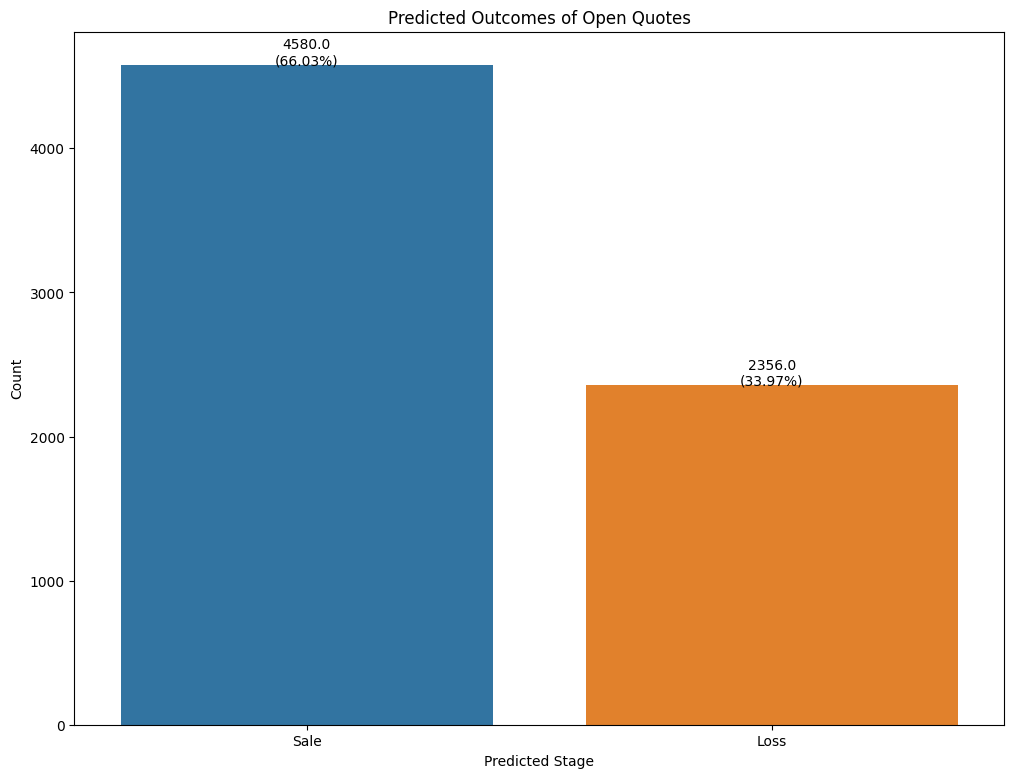

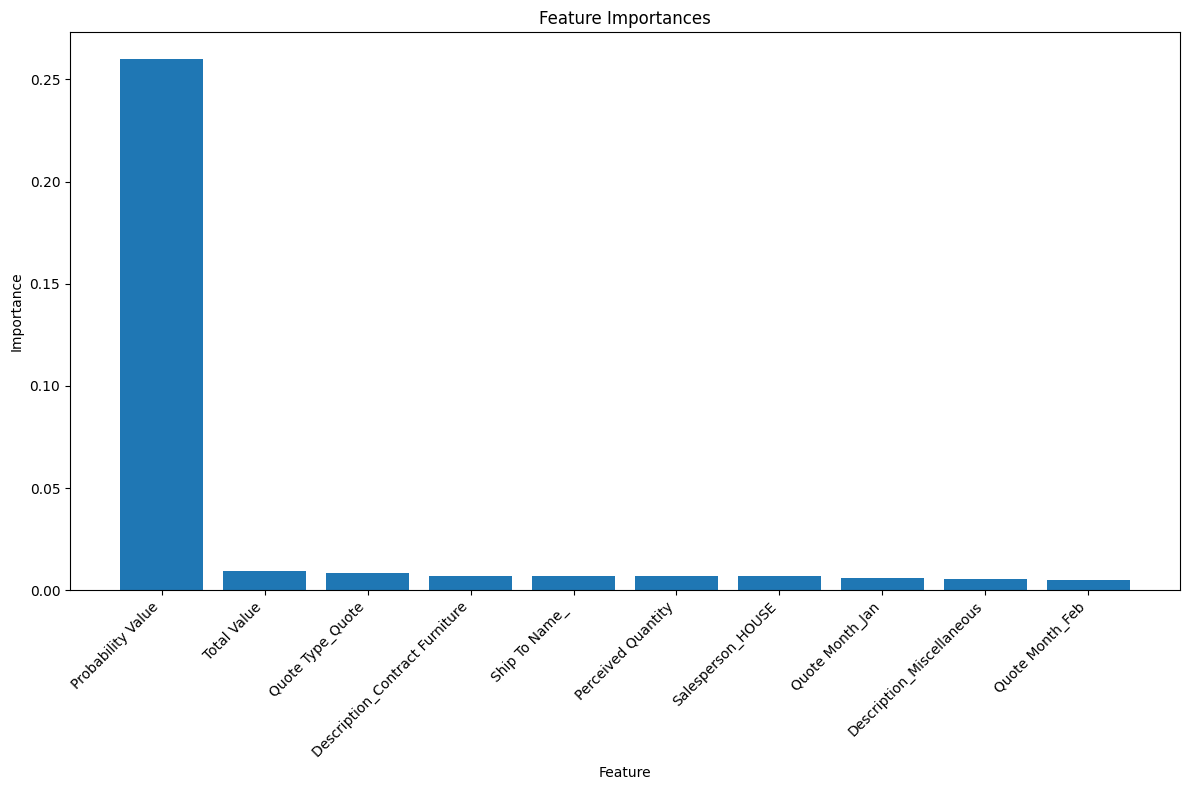

Feature ranking:
1. feature 3 (0.260022210401551) - Probability Value
2. feature 2 (0.009474183080289845) - Total Value
3. feature 14840 (0.008430050652947732) - Quote Type_Quote
4. feature 3005 (0.007095756098920389) - Description_Contract Furniture
5. feature 7379 (0.007022255078767997) - Ship To Name_ 
6. feature 1 (0.006829881631157417) - Perceived Quantity
7. feature 3150 (0.0067279938463441795) - Salesperson_HOUSE
8. feature 35595 (0.006010277283478047) - Quote Month_Jan
9. feature 3014 (0.005423631968302753) - Description_Miscellaneous
10. feature 35594 (0.00522410159634179) - Quote Month_Feb


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading the data
data = pd.read_excel(r'C:\Users\moses_y\OneDrive\Desktop\ML Projects\Pipeline\Quote Pipeline.xlsx', header=1)

# Print column names to verify
print("Columns in the dataset:", data.columns)

# Strip leading/trailing spaces from column names
data.columns = data.columns.str.strip()

# Check if 'Stage' is in the columns
if 'Stage' not in data.columns:
    raise KeyError("The 'Stage' column is not found in the dataset. Please check the column names.")

# Handling Missing Values
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
print(missing_percentage)

# Drop columns with more than 25% missing values
threshold = 25
data_dropped = data.loc[:, missing_percentage < threshold]
print(f"Columns after dropping those with >{threshold}% missing values:", data_dropped.columns)

# Drop specified columns
data_dropped = data_dropped.drop(columns=['Document Month', 'Market Channel'])

# Identify categorical and numerical columns
categorical_features = data_dropped.select_dtypes(include=['object']).columns
numerical_features = data_dropped.select_dtypes(include=[np.number]).columns

# Remove 'Stage' from categorical_features if present
if 'Stage' in categorical_features:
    categorical_features = categorical_features.drop('Stage')

# Impute missing values
categorical_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
data_dropped.loc[:, categorical_features] = categorical_imputer.fit_transform(data_dropped.loc[:, categorical_features])

numerical_imputer = SimpleImputer(strategy='most_frequent')
data_dropped.loc[:, numerical_features] = numerical_imputer.fit_transform(data_dropped.loc[:, numerical_features])

# Map 'Stage' column to combined classes
stage_mapping = {
    'lost': 0,
    'sale': 1,
    'open': 2,
    'open - new': 2,
    'open - active review': 2,
    'open - gained apprvl': 2,
    'unknown': 3
}
data_dropped['Stage'] = data_dropped['Stage'].str.lower().map(stage_mapping)

# Drop rows with missing 'Stage' values
data_dropped.dropna(subset=['Stage'], inplace=True)

# Separate open quotes
open_quotes = data_dropped[data_dropped['Stage'] == 2]
historical_data = data_dropped[data_dropped['Stage'] != 2]

# Encode Categorical Variables with Sparse Matrix
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoded_features = encoder.fit_transform(historical_data[categorical_features])

# Combine numerical and encoded categorical features
numerical_df = pd.DataFrame(historical_data[numerical_features], columns=numerical_features)
data_final_sparse = sparse.hstack([sparse.csr_matrix(numerical_df.values), encoded_features])

# Splitting the data into training and testing sets
X = data_final_sparse
y = historical_data['Stage']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Applying SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Model Building: Random Forest Classifier for binary classification (sale vs loss)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_balanced, y_train_balanced)

# Model Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))


# Prepare open quotes for prediction
encoded_open_features = encoder.transform(open_quotes[categorical_features])
numerical_open_df = pd.DataFrame(open_quotes[numerical_features], columns=numerical_features)
open_data_final_sparse = sparse.hstack([sparse.csr_matrix(numerical_open_df.values), encoded_open_features])

# Predict outcomes for open quotes
open_quotes['Predicted_Stage'] = model.predict(open_data_final_sparse)
open_quotes['Predicted_Stage'] = open_quotes['Predicted_Stage'].map({0: 'Loss', 1: 'Sale'})

# Display predictions
print(open_quotes[['Quote #', 'Predicted_Stage']])

# Plot the predicted outcomes of open quotes with count and percentage annotations
plt.figure(figsize=(12, 9))
ax = sns.countplot(x='Predicted_Stage', data=open_quotes, order=['Sale', 'Loss'])
plt.title('Predicted Outcomes of Open Quotes')
plt.xlabel('Predicted Stage')
plt.ylabel('Count')

# Annotate each bar with the count and percentage
total = len(open_quotes)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.2f}%'
    ax.annotate(f'{count}\n({percentage})', (p.get_x() + p.get_width() / 2., count), ha='center', va='baseline')

plt.show()

# Feature Importance Plot
feature_names = numerical_features.tolist() + encoder.get_feature_names_out(categorical_features).tolist()
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importance
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(10), importances[indices][:10], align='center')
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Print the feature ranking
print("Feature ranking:")
for f in range(10):
    print(f"{f + 1}. feature {indices[f]} ({importances[indices[f]]}) - {feature_names[indices[f]]}")
